# Neural ODEs, Continuous Normalizing Flows, and KAN

This notebook covers the family of continuous-depth models introduced by Chen et al. (2018) and related architectures. We explore how treating neural network depth as a continuous variable leads to elegant formulations for generative models, time-series modeling, and physics-inspired networks.

**Topics covered:**
1. ODE Review
2. Neural ODEs (Chen et al. 2018)
3. Adjoint Method for Backpropagation
4. ODE Solvers: Euler, RK4, Dopri5
5. FFJORD (Free-Form Continuous Normalizing Flows)
6. Latent ODEs for Time Series
7. GRU-ODE-Bayes for Irregular Time Series
8. Hamiltonian Neural Networks
9. Lagrangian Neural Networks
10. Normalizing Flows (NICE, RealNVP, Glow, MAF, IAF)
11. Continuous Normalizing Flows
12. Kolmogorov-Arnold Networks (KAN)

## 1. ODE Review

An **Ordinary Differential Equation (ODE)** describes how a quantity changes continuously over time. The general first-order ODE initial value problem (IVP) is:

$$\frac{d\mathbf{z}(t)}{dt} = f(\mathbf{z}(t), t), \quad \mathbf{z}(t_0) = \mathbf{z}_0$$

The solution $\mathbf{z}(t_1)$ at time $t_1$ is found by integrating:

$$\mathbf{z}(t_1) = \mathbf{z}(t_0) + \int_{t_0}^{t_1} f(\mathbf{z}(t), t)\, dt$$

**Key concepts:**
- **Phase portrait**: Visualization of trajectories in state space
- **Fixed points**: States where $f(\mathbf{z}^*, t) = 0$
- **Stability**: Whether perturbations from fixed points grow or decay
- **Lipschitz continuity**: $\|f(\mathbf{z}_1) - f(\mathbf{z}_2)\| \leq L\|\mathbf{z}_1 - \mathbf{z}_2\|$ guarantees unique solutions (Picard-Lindelof theorem)

**Connection to ResNets**: A ResNet layer computes $\mathbf{h}_{t+1} = \mathbf{h}_t + f(\mathbf{h}_t, \theta_t)$, which is exactly an Euler discretization of an ODE with step size 1.

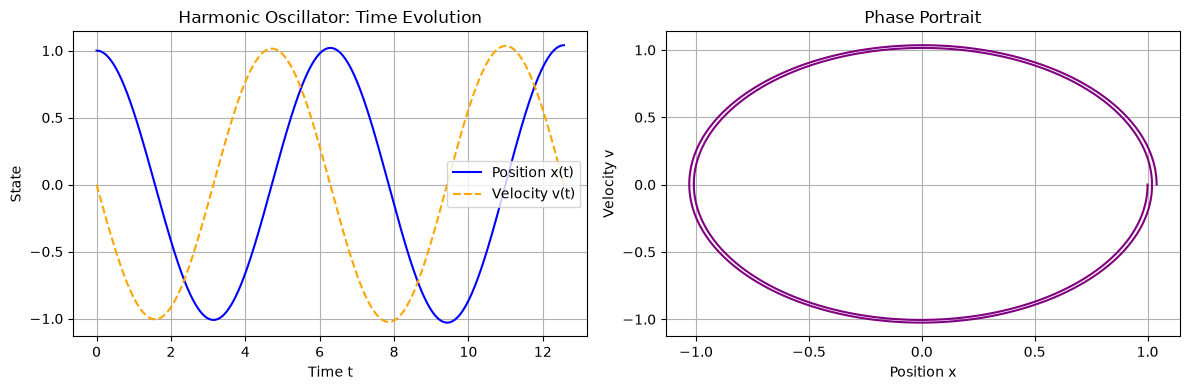

Euler ODE solve complete


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Simple ODE example: harmonic oscillator
# dz/dt = [z[1], -z[0]]  =>  d^2x/dt^2 + x = 0

def harmonic_oscillator(z, t):
    """Returns dz/dt for the harmonic oscillator."""
    return np.array([z[1], -z[0]])

def euler_solve(f, z0, t_span, n_steps=1000):
    """Simple Euler method ODE solver."""
    t0, t1 = t_span
    dt = (t1 - t0) / n_steps
    t = np.linspace(t0, t1, n_steps + 1)
    z = np.zeros((n_steps + 1, len(z0)))
    z[0] = z0
    for i in range(n_steps):
        z[i+1] = z[i] + dt * f(z[i], t[i])
    return t, z

# Solve the harmonic oscillator
z0 = np.array([1.0, 0.0])  # initial position=1, velocity=0
t, z = euler_solve(harmonic_oscillator, z0, (0, 4*np.pi), n_steps=2000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t, z[:, 0], label='Position x(t)', color='blue')
axes[0].plot(t, z[:, 1], label='Velocity v(t)', color='orange', linestyle='--')
axes[0].set_xlabel('Time t')
axes[0].set_ylabel('State')
axes[0].set_title('Harmonic Oscillator: Time Evolution')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(z[:, 0], z[:, 1], color='purple')
axes[1].set_xlabel('Position x')
axes[1].set_ylabel('Velocity v')
axes[1].set_title('Phase Portrait')
axes[1].grid(True)

plt.tight_layout()
plt.show()
print('Euler ODE solve complete')

## 2. Neural ODEs

**Chen et al. (2018)** *Neural Ordinary Differential Equations* (NeurIPS 2018) proposed replacing discrete residual layers with a continuous-time ODE:

$$\frac{d\mathbf{h}(t)}{dt} = f(\mathbf{h}(t), t, \theta)$$

where $f$ is a neural network parameterized by $\theta$.

**Forward pass**: Given initial state $\mathbf{h}(t_0)$, compute output $\mathbf{h}(t_1)$ by calling an ODE solver:

$$\mathbf{h}(t_1) = \mathbf{h}(t_0) + \int_{t_0}^{t_1} f(\mathbf{h}(t), t, \theta)\, dt = \text{ODESolve}(f, \mathbf{h}(t_0), t_0, t_1, \theta)$$

**Key advantages over ResNets:**
- **Memory efficiency**: $O(1)$ memory regardless of depth (using adjoint method)
- **Adaptive computation**: ODE solver chooses number of function evaluations
- **Exact gradients**: Adjoint method computes exact gradients
- **Continuous dynamics**: Natural for time-series and physical systems
- **Invertibility**: The flow map $\phi_t: \mathbf{h}(t_0) \mapsto \mathbf{h}(t_1)$ is a diffeomorphism

**Connection to ResNets**: As step size $\Delta t \to 0$, a ResNet $\mathbf{h}_{t+1} = \mathbf{h}_t + f(\mathbf{h}_t, \theta_t)$ converges to a Neural ODE.

In [2]:
# Install torchdiffeq if needed
# !pip install torchdiffeq

try:
    from torchdiffeq import odeint, odeint_adjoint
    TORCHDIFFEQ_AVAILABLE = True
    print('torchdiffeq available')
except ImportError:
    TORCHDIFFEQ_AVAILABLE = False
    print('torchdiffeq not installed. Using manual implementations.')

# Manual RK4 solver for demonstration
def rk4_step(f, y, t, dt):
    """Single RK4 step."""
    k1 = f(t, y)
    k2 = f(t + dt/2, y + dt * k1 / 2)
    k3 = f(t + dt/2, y + dt * k2 / 2)
    k4 = f(t + dt,   y + dt * k3)
    return y + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)

def rk4_solve(f, y0, t_eval):
    """RK4 solver over a time grid."""
    ys = [y0]
    y = y0
    for i in range(len(t_eval) - 1):
        dt = t_eval[i+1] - t_eval[i]
        y = rk4_step(f, y, t_eval[i], dt)
        ys.append(y)
    return torch.stack(ys)

# Define a simple Neural ODE dynamics function
class ODEFunc(nn.Module):
    """The dynamics network f(h, t, theta)."""
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.nfe = 0  # number of function evaluations

    def forward(self, t, h):
        self.nfe += 1
        return self.net(h)

# Neural ODE block
class NeuralODE(nn.Module):
    def __init__(self, func, t_span=(0.0, 1.0), method='rk4'):
        super().__init__()
        self.func = func
        self.t_span = t_span
        self.method = method

    def forward(self, h0):
        t = torch.tensor(self.t_span, dtype=h0.dtype, device=h0.device)
        if TORCHDIFFEQ_AVAILABLE:
            # Use adjoint method for memory-efficient backprop
            out = odeint_adjoint(self.func, h0, t, method=self.method)
            return out[-1]  # return state at t1
        else:
            # Fallback to manual RK4
            t_eval = torch.linspace(self.t_span[0], self.t_span[1], 10, dtype=h0.dtype)
            out = rk4_solve(self.func, h0, t_eval)
            return out[-1]

# Create a simple classifier using Neural ODE
class NeuralODEClassifier(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64, output_dim=2):
        super().__init__()
        self.encoder = nn.Linear(input_dim, hidden_dim)
        self.ode_func = ODEFunc(hidden_dim)
        self.ode = NeuralODE(self.ode_func)
        self.decoder = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.tanh(self.encoder(x))
        h1 = self.ode(h0)
        return self.decoder(h1)

# Quick test
model = NeuralODEClassifier(input_dim=2, hidden_dim=32, output_dim=2)
x_test = torch.randn(8, 2)
y_test = model(x_test)
print(f'NeuralODE Classifier output shape: {y_test.shape}')
print(f'Number of function evaluations: {model.ode_func.nfe}')

torchdiffeq available
NeuralODE Classifier output shape: torch.Size([8, 2])
Number of function evaluations: 4


## 3. Adjoint Method for Backpropagation

Direct backpropagation through an ODE solver requires storing all intermediate states, which is $O(N)$ in memory where $N$ is the number of solver steps. The **adjoint method** reduces this to $O(1)$ memory.

**Adjoint state**: Define the adjoint $\mathbf{a}(t) = \frac{d\mathcal{L}}{d\mathbf{h}(t)}$ (gradient of loss with respect to hidden state at time $t$).

The adjoint evolves backwards in time according to:

$$\frac{d\mathbf{a}(t)}{dt} = -\mathbf{a}(t)^T \frac{\partial f(\mathbf{h}(t), t, \theta)}{\partial \mathbf{h}(t)}$$

The gradient of the loss with respect to parameters is:

$$\frac{d\mathcal{L}}{d\theta} = -\int_{t_1}^{t_0} \mathbf{a}(t)^T \frac{\partial f}{\partial \theta}\, dt$$

where $\mathbf{a}(t) = \frac{d\mathcal{L}}{d\mathbf{h}(t)}$.

**Algorithm (backward pass):**
1. Start with $\mathbf{a}(t_1) = \frac{d\mathcal{L}}{d\mathbf{h}(t_1)}$ (gradient at output)
2. Solve the **augmented ODE** backwards from $t_1$ to $t_0$:
   $$\frac{d}{dt}\begin{pmatrix}\mathbf{h}\\ \mathbf{a}\\ \frac{d\mathcal{L}}{d\theta}\end{pmatrix} = \begin{pmatrix}f\\ -\mathbf{a}^T\partial_\mathbf{h}f\\ -\mathbf{a}^T\partial_\theta f\end{pmatrix}$$
3. The recovered $\mathbf{h}(t_0)$ and accumulated $\frac{d\mathcal{L}}{d\theta}$ give all needed gradients.

**Key insight**: We only need to store $\mathbf{h}(t_1)$ and run the ODE solver once forward and once backward no intermediate activations needed.

In [3]:
# Demonstrate adjoint method concept via manual augmented ODE
import torch
import torch.nn as nn

class AugmentedDynamics(nn.Module):
    """
    Augmented ODE for the adjoint method.
    State: (h, a, grad_theta) where a = dL/dh
    """
    def __init__(self, func):
        super().__init__()
        self.func = func

    def forward(self, t, state):
        h, a = state[:, :h.shape[1]], state[:, h.shape[1]:]
        with torch.enable_grad():
            h_req = h.requires_grad_(True)
            fh = self.func(t, h_req)
            # dL/dh dynamics: -a^T * df/dh
            dadh = torch.autograd.grad(
                fh, h_req,
                grad_outputs=a,
                create_graph=False,
                retain_graph=True
            )[0]
        dh = fh
        da = -dadh
        return torch.cat([dh, da], dim=1)

# Demonstrate gradient computation through Neural ODE
print('Adjoint method key equations:')
print('  Forward:  h(t1) = ODESolve(f, h(t0), t0, t1)')
print('  Adjoint:  da/dt = -a^T * df/dh')
print('  Gradient: dL/dtheta = -integral(a^T * df/dtheta) dt')
print()

# Show that torchdiffeq's odeint_adjoint handles this automatically
if TORCHDIFFEQ_AVAILABLE:
    func = ODEFunc(hidden_dim=16)
    h0 = torch.randn(4, 16, requires_grad=True)
    t = torch.tensor([0.0, 1.0])

    # odeint_adjoint uses O(1) memory (adjoint method)
    h_traj = odeint_adjoint(func, h0, t, method='rk4')
    loss = h_traj[-1].sum()
    loss.backward()

    print(f'h0 grad shape (adjoint method): {h0.grad.shape}')
    print(f'Param grad norm: {sum(p.grad.norm().item() for p in func.parameters() if p.grad is not None):.4f}')
    print(f'NFE (function evaluations): {func.nfe}')
else:
    print('Install torchdiffeq to see adjoint method in action.')
    print('pip install torchdiffeq')

Adjoint method key equations:
  Forward:  h(t1) = ODESolve(f, h(t0), t0, t1)
  Adjoint:  da/dt = -a^T * df/dh
  Gradient: dL/dtheta = -integral(a^T * df/dtheta) dt



h0 grad shape (adjoint method): torch.Size([4, 16])
Param grad norm: 52.5446
NFE (function evaluations): 8


## 4. ODE Solvers: Euler, RK4, Dopri5

### 4.1 Euler Method (Order 1)
$$\mathbf{z}_{n+1} = \mathbf{z}_n + h \cdot f(\mathbf{z}_n, t_n)$$
- Local error: $O(h^2)$, global error: $O(h)$
- Simple but inaccurate for large step sizes

### 4.2 Runge-Kutta 4 (RK4, Order 4)
$$k_1 = f(\mathbf{z}_n, t_n)$$
$$k_2 = f\!\left(\mathbf{z}_n + \tfrac{h}{2}k_1,\, t_n + \tfrac{h}{2}\right)$$
$$k_3 = f\!\left(\mathbf{z}_n + \tfrac{h}{2}k_2,\, t_n + \tfrac{h}{2}\right)$$
$$k_4 = f(\mathbf{z}_n + h k_3,\, t_n + h)$$
$$\mathbf{z}_{n+1} = \mathbf{z}_n + \tfrac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)$$
- Local error: $O(h^5)$, global error: $O(h^4)$
- 4 function evaluations per step

### 4.3 Dormand-Prince (Dopri5, Order 4/5)
An **adaptive** step-size method using 7 function evaluations to compute both 4th- and 5th-order solutions. The difference estimates the local error, allowing dynamic step-size control:
$$h_{\text{new}} = h \cdot \min\!\left(h_{\max}, \max\!\left(h_{\min},\, S \cdot \left(\frac{\text{tol}}{\|e\|}\right)^{1/5}\right)\right)$$
where $S \approx 0.9$ is a safety factor and $\|e\|$ is the estimated error.

Dopri5 is the default in `torchdiffeq` and corresponds to MATLAB's `ode45`.

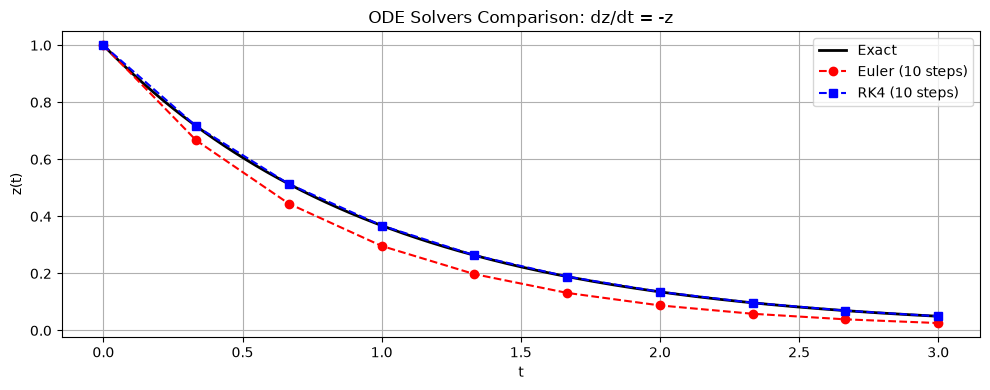

Mean Absolute Error (10 steps):
  Euler: 0.322392
  RK4:   0.318720
  RK4 is 1.0x more accurate


In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Compare Euler, RK4, and exact solution on a simple ODE
# dz/dt = -z (exact: z(t) = z0 * exp(-t))

def f_decay(t, z):
    return -z

def euler_torch(f, z0, t_eval):
    zs = [z0]
    z = z0
    for i in range(len(t_eval) - 1):
        dt = t_eval[i+1] - t_eval[i]
        z = z + dt * f(t_eval[i], z)
        zs.append(z)
    return torch.stack(zs)

def rk4_torch(f, z0, t_eval):
    zs = [z0]
    z = z0
    for i in range(len(t_eval) - 1):
        t = t_eval[i]
        dt = t_eval[i+1] - t_eval[i]
        k1 = f(t, z)
        k2 = f(t + dt/2, z + dt * k1 / 2)
        k3 = f(t + dt/2, z + dt * k2 / 2)
        k4 = f(t + dt,   z + dt * k3)
        z = z + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)
        zs.append(z)
    return torch.stack(zs)

# Test with a coarse grid to see differences
t_eval_coarse = torch.linspace(0, 3, 10)  # only 10 steps
t_eval_fine   = torch.linspace(0, 3, 500)
z0 = torch.tensor([1.0])

z_euler  = euler_torch(f_decay, z0, t_eval_coarse)
z_rk4    = rk4_torch(f_decay, z0, t_eval_coarse)
z_exact  = z0 * torch.exp(-t_eval_fine)

plt.figure(figsize=(10, 4))
plt.plot(t_eval_fine.numpy(), z_exact.numpy(), 'k-', label='Exact', linewidth=2)
plt.plot(t_eval_coarse.numpy(), z_euler.numpy(), 'ro--', label=f'Euler (10 steps)')
plt.plot(t_eval_coarse.numpy(), z_rk4.numpy(), 'bs--', label=f'RK4 (10 steps)')
plt.xlabel('t')
plt.ylabel('z(t)')
plt.title('ODE Solvers Comparison: dz/dt = -z')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Compute errors
z_exact_coarse = z0 * torch.exp(-t_eval_coarse)
euler_err = (z_euler - z_exact_coarse).abs().mean().item()
rk4_err   = (z_rk4   - z_exact_coarse).abs().mean().item()
print(f'Mean Absolute Error (10 steps):')
print(f'  Euler: {euler_err:.6f}')
print(f'  RK4:   {rk4_err:.6f}')
print(f'  RK4 is {euler_err/rk4_err:.1f}x more accurate')

## 5. FFJORD Free-Form Continuous Normalizing Flows

**Grathwohl et al. (2018)** extended Neural ODEs to generative modeling by combining them with the **instantaneous change of variables** formula.

For a continuous normalizing flow, the log-density evolves as:

$$\frac{d\log p(\mathbf{z}(t))}{dt} = -\text{Tr}\!\left(\frac{\partial f}{\partial \mathbf{z}(t)}\right)$$

**Problem**: Computing $\text{Tr}(\partial f/\partial \mathbf{z})$ exactly costs $O(d^2)$ or $O(d)$ with the Jacobian.

**FFJORD's solution Hutchinson Trace Estimator**:

$$\text{Tr}(A) = \mathbb{E}_{\mathbf{\epsilon} \sim p(\mathbf{\epsilon})}\!\left[\mathbf{\epsilon}^T A\, \mathbf{\epsilon}\right], \quad \mathbb{E}[\mathbf{\epsilon}] = 0,\ \mathbb{E}[\mathbf{\epsilon}\mathbf{\epsilon}^T] = I$$

Using $\mathbf{\epsilon} \sim \mathcal{N}(0, I)$ or Rademacher distribution $\pm 1$:

$$\text{Tr}\!\left(\frac{\partial f}{\partial \mathbf{z}}\right) \approx \mathbf{\epsilon}^T \frac{\partial f}{\partial \mathbf{z}} \mathbf{\epsilon} = \mathbf{\epsilon}^T \frac{\partial (f \cdot \mathbf{\epsilon})}{\partial \mathbf{z}}$$

The key insight: $\mathbf{\epsilon}^T \frac{\partial f}{\partial \mathbf{z}} \mathbf{\epsilon}$ can be computed via a **single VJP** (vector-Jacobian product) same cost as one backward pass through $f$.

**Full FFJORD objective**:
$$\log p(\mathbf{x}) = \log p(\mathbf{z}(t_1)) + \int_{t_0}^{t_1} \text{Tr}\!\left(\frac{\partial f}{\partial \mathbf{z}}\right) dt$$

In [5]:
import torch
import torch.nn as nn

def hutchinson_trace_estimator(f_output, z, noise=None, n_samples=1):
    """
    Hutchinson trace estimator for Tr(df/dz).
    Uses: Tr(A) = E[eps^T A eps] where E[eps eps^T] = I
    """
    if noise is None:
        # Rademacher noise (often lower variance than Gaussian)
        noise = torch.randint(0, 2, z.shape, dtype=z.dtype, device=z.device) * 2 - 1

    # VJP: eps^T * (df/dz)
    vjp = torch.autograd.grad(
        f_output, z,
        grad_outputs=noise,
        create_graph=True,
        retain_graph=True
    )[0]

    # Tr(df/dz) approx = eps^T * (df/dz) * eps = vjp . eps
    trace_est = (vjp * noise).sum(dim=-1)  # sum over features
    return trace_est

class FFJORDDynamics(nn.Module):
    """FFJORD dynamics: augmented ODE with log-density trace."""
    def __init__(self, dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, hidden_dim),  # +1 for time
            nn.Softplus(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Softplus(),
            nn.Linear(hidden_dim, dim)
        )
        self.nfe = 0

    def forward(self, t, state):
        self.nfe += 1
        # state = (z, log_p) concatenated
        z = state[:, :-1]
        # Append time to input
        t_vec = torch.ones(z.shape[0], 1, device=z.device, dtype=z.dtype) * t
        zt = torch.cat([z, t_vec], dim=1)

        with torch.enable_grad():
            z_req = z.requires_grad_(True)
            zt_req = torch.cat([z_req, t_vec], dim=1)
            f = self.net(zt_req)
            # Estimate trace of Jacobian
            div = hutchinson_trace_estimator(f, z_req)

        # Return (dz/dt, d_log_p/dt)
        return torch.cat([f, -div.unsqueeze(1)], dim=1)

# Test FFJORD dynamics
dim = 2
ffjord = FFJORDDynamics(dim=dim, hidden_dim=32)
z0 = torch.randn(4, dim)
logp0 = torch.zeros(4, 1)
state0 = torch.cat([z0, logp0], dim=1)

state0_req = state0.requires_grad_(True)
dstate = ffjord(torch.tensor(0.5), state0)

print(f'FFJORD state shape: {state0.shape}')
print(f'dz/dt shape: {dstate[:, :-1].shape}')
print(f'd_logp/dt shape: {dstate[:, -1:].shape}')
print(f'd_logp/dt (trace estimates): {dstate[:, -1].detach().numpy()}')
print()
print('Hutchinson trace estimator: Tr(A) = E[eps^T A eps]')
print('Cost: O(d) VJP instead of O(d^2) full Jacobian')

FFJORD state shape: torch.Size([4, 3])
dz/dt shape: torch.Size([4, 2])
d_logp/dt shape: torch.Size([4, 1])
d_logp/dt (trace estimates): [ 0.05551133 -0.05171918  0.06009575  0.07161821]

Hutchinson trace estimator: Tr(A) = E[eps^T A eps]
Cost: O(d) VJP instead of O(d^2) full Jacobian


## 6. Latent ODEs for Time Series

**Rubanova et al. (2019)** *Latent Ordinary Differential Equations for Irregularly-Sampled Time Series* proposed modeling time series with a latent ODE.

**Architecture (VAE + ODE):**
1. **Recognition network** (RNN running backwards): Encodes observations $\{(\mathbf{x}_i, t_i)\}$ into a latent initial state distribution $q(\mathbf{z}_{t_0} | \{\mathbf{x}_i\})$
2. **Latent ODE**: Evolves latent state $\mathbf{z}(t)$ continuously: $\frac{d\mathbf{z}}{dt} = f_\theta(\mathbf{z}, t)$
3. **Decoder**: Maps latent state to observations: $\mathbf{x}(t) = g_\phi(\mathbf{z}(t))$

**Key advantages:**
- Handles **irregular** observation times naturally
- Can predict at any future time
- Missing data handled gracefully

**ELBO objective** (Evidence Lower BOund):
$$\mathcal{L} = \mathbb{E}_{q(\mathbf{z}_{t_0})}\left[\sum_i \log p(\mathbf{x}_{t_i} | \mathbf{z}_{t_i})\right] - \text{KL}\!\left(q(\mathbf{z}_{t_0}) \,\|\, p(\mathbf{z}_{t_0})\right)$$

where $\mathbf{z}_{t_i} = \text{ODESolve}(f_\theta, \mathbf{z}_{t_0}, t_0, t_i)$.

In [6]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

class RecognitionRNN(nn.Module):
    """Encodes irregular time series into latent initial state."""
    def __init__(self, obs_dim, latent_dim, hidden_dim=64):
        super().__init__()
        self.hidden_dim = hidden_dim
        # Input: observation + time delta
        self.gru = nn.GRUCell(obs_dim + 1, hidden_dim)
        self.to_mean = nn.Linear(hidden_dim, latent_dim)
        self.to_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, obs_seq, t_seq):
        """
        obs_seq: (T, batch, obs_dim)
        t_seq:   (T, batch) observation times
        Run backwards through time.
        """
        batch_size = obs_seq.shape[1]
        h = torch.zeros(batch_size, self.hidden_dim, device=obs_seq.device)

        # Process in reverse time order
        for i in range(obs_seq.shape[0] - 1, -1, -1):
            obs_t = obs_seq[i]
            dt = t_seq[i].unsqueeze(1)
            inp = torch.cat([obs_t, dt], dim=1)
            h = self.gru(inp, h)

        mean = self.to_mean(h)
        logvar = self.to_logvar(h)
        return mean, logvar

class LatentODEFunc(nn.Module):
    """ODE dynamics in latent space."""
    def __init__(self, latent_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, latent_dim)
        )

    def forward(self, t, z):
        return self.net(z)

class LatentODE(nn.Module):
    """Full Latent ODE model for irregular time series."""
    def __init__(self, obs_dim=1, latent_dim=4, hidden_dim=32):
        super().__init__()
        self.encoder = RecognitionRNN(obs_dim, latent_dim, hidden_dim)
        self.ode_func = LatentODEFunc(latent_dim, hidden_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, obs_dim)
        )

    def reparameterize(self, mean, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mean + eps * std

    def forward(self, obs_seq, t_obs, t_pred):
        # Encode
        mean, logvar = self.encoder(obs_seq, t_obs)
        z0 = self.reparameterize(mean, logvar)

        # Solve ODE at prediction times (manual RK4 here)
        z_traj = rk4_solve(self.ode_func, z0, t_pred)

        # Decode
        pred = self.decoder(z_traj)

        return pred, mean, logvar

# Synthetic irregular time series
T, batch, obs_dim = 15, 4, 1
obs_seq = torch.randn(T, batch, obs_dim)
t_obs   = torch.rand(T, batch) * 0.1  # random time deltas
t_pred  = torch.linspace(0, 1, 20)

model = LatentODE(obs_dim=obs_dim, latent_dim=4, hidden_dim=32)
pred, mean, logvar = model(obs_seq, t_obs, t_pred)
print(f'Latent ODE prediction shape: {pred.shape}  (time, batch, obs_dim)')
print(f'Latent mean shape: {mean.shape}')

# KL divergence
kl = -0.5 * (1 + logvar - mean.pow(2) - logvar.exp()).sum()
print(f'KL divergence: {kl.item():.4f}')

Latent ODE prediction shape: torch.Size([20, 4, 1])  (time, batch, obs_dim)
Latent mean shape: torch.Size([4, 4])
KL divergence: 0.1298


## 7. GRU-ODE-Bayes for Irregular Time Series

**De Brouwer et al. (2019)** *GRU-ODE-Bayes* combines ODE-based continuous dynamics between observations with GRU-style updates at observation times.

**Model:**
1. **Between observations** (continuous): Evolve hidden state with ODE:
   $$\frac{d\mathbf{h}(t)}{dt} = g(\mathbf{h}(t), t, \theta)$$
   where $g$ is a GRU-like update without input:
   $$\frac{d\mathbf{h}}{dt} = \tanh(\mathbf{W}_h \mathbf{h})\cdot(1 - \mathbf{h})$$

2. **At observation times** (discrete): Apply Bayesian update (or standard GRU update):
   $$\mathbf{h}(t_i^+) = \text{GRUCell}(\mathbf{x}(t_i), \mathbf{h}(t_i^-))$$

**Advantages over standard GRU/LSTM:**
- Handles **arbitrarily irregular** observation times
- Natural uncertainty quantification via Bayesian updates
- Continuous latent state trajectory
- Missing values handled by skipping GRU update

**GRU-ODE dynamics:**
$$\frac{d\mathbf{h}}{dt} = (1 - \mathbf{z}) \odot (\mathbf{r} \odot \tanh(\mathbf{W}_h \mathbf{h}) - \mathbf{h})$$

In [7]:
import torch
import torch.nn as nn

class GRUODECell(nn.Module):
    """
    GRU-ODE cell: continuous dynamics between observations.
    dh/dt = (1 - z) * (candidate - h)
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        # GRU gates without input
        self.W_z = nn.Linear(hidden_dim, hidden_dim)
        self.W_r = nn.Linear(hidden_dim, hidden_dim)
        self.W_h = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, t, h):
        """Returns dh/dt."""
        z = torch.sigmoid(self.W_z(h))       # update gate
        r = torch.sigmoid(self.W_r(h))       # reset gate
        h_tilde = torch.tanh(self.W_h(r * h))  # candidate
        dh = (1 - z) * (h_tilde - h)
        return dh

class GRUODEBayes(nn.Module):
    """
    GRU-ODE-Bayes: continuous dynamics + discrete observation updates.
    """
    def __init__(self, obs_dim, hidden_dim=64):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.ode_cell = GRUODECell(hidden_dim)
        # Standard GRU for observation updates
        self.obs_gru = nn.GRUCell(obs_dim, hidden_dim)
        self.output_layer = nn.Linear(hidden_dim, obs_dim)

    def ode_step(self, h, dt, n_steps=5):
        """Evolve h over interval dt using Euler steps."""
        step = dt / n_steps
        for _ in range(n_steps):
            dh = self.ode_cell(None, h)
            h = h + step * dh
        return h

    def forward(self, obs_list, t_list):
        """
        obs_list: list of (batch, obs_dim) tensors or None (missing)
        t_list:   list of observation times
        Returns: list of hidden states and predictions
        """
        batch_size = obs_list[0].shape[0] if obs_list[0] is not None else 1
        h = torch.zeros(batch_size, self.hidden_dim)
        predictions = []
        hidden_states = []

        prev_t = 0.0
        for obs, t in zip(obs_list, t_list):
            dt = t - prev_t

            # Step 1: Continuous ODE evolution between observations
            if dt > 0:
                h = self.ode_step(h, dt)

            # Step 2: Bayesian/GRU update at observation time
            if obs is not None:  # skip if missing
                h = self.obs_gru(obs, h)

            pred = self.output_layer(h)
            predictions.append(pred)
            hidden_states.append(h)
            prev_t = t

        return predictions, hidden_states

# Test with irregular time series (some missing values)
batch, obs_dim = 4, 2
model = GRUODEBayes(obs_dim=obs_dim, hidden_dim=32)

# Irregular times with missing value at t=1.5
times = [0.0, 0.3, 0.7, 1.0, 1.5, 2.1, 3.0]
obs_list = [
    torch.randn(batch, obs_dim),  # t=0.0
    torch.randn(batch, obs_dim),  # t=0.3
    None,                          # t=0.7 (missing)
    torch.randn(batch, obs_dim),  # t=1.0
    torch.randn(batch, obs_dim),  # t=1.5
    None,                          # t=2.1 (missing)
    torch.randn(batch, obs_dim),  # t=3.0
]

preds, hiddens = model(obs_list, times)
print(f'GRU-ODE-Bayes predictions at {len(preds)} time points')
print(f'Each prediction shape: {preds[0].shape}')
print(f'Handles missing values (None): Yes')
print(f'Handles irregular spacing: Yes')

GRU-ODE-Bayes predictions at 7 time points
Each prediction shape: torch.Size([4, 2])
Handles missing values (None): Yes
Handles irregular spacing: Yes


## 8. Hamiltonian Neural Networks

**Greydanus et al. (2019)** proposed learning the **Hamiltonian** $\mathcal{H}(\mathbf{q}, \mathbf{p})$ of a physical system directly from data, ensuring exact energy conservation.

**Hamilton's equations:**
$$\frac{d\mathbf{q}}{dt} = \frac{\partial \mathcal{H}}{\partial \mathbf{p}}, \qquad \frac{d\mathbf{p}}{dt} = -\frac{\partial \mathcal{H}}{\partial \mathbf{q}}$$

where $\mathbf{q}$ are generalized coordinates and $\mathbf{p}$ are conjugate momenta.

**Key property**: The Hamiltonian $\mathcal{H}$ is conserved: $\frac{d\mathcal{H}}{dt} = 0$.

**Proof**: $\frac{d\mathcal{H}}{dt} = \frac{\partial \mathcal{H}}{\partial \mathbf{q}} \dot{\mathbf{q}} + \frac{\partial \mathcal{H}}{\partial \mathbf{p}} \dot{\mathbf{p}} = \frac{\partial \mathcal{H}}{\partial \mathbf{q}} \frac{\partial \mathcal{H}}{\partial \mathbf{p}} - \frac{\partial \mathcal{H}}{\partial \mathbf{p}} \frac{\partial \mathcal{H}}{\partial \mathbf{q}} = 0$

**HNN Architecture:**
- Neural network $\mathcal{H}_\theta(\mathbf{q}, \mathbf{p})$ approximates the Hamiltonian
- Dynamics computed via automatic differentiation:
  $$\dot{\mathbf{q}} = \frac{\partial \mathcal{H}_\theta}{\partial \mathbf{p}}, \quad \dot{\mathbf{p}} = -\frac{\partial \mathcal{H}_\theta}{\partial \mathbf{q}}$$
- **Loss**: $\mathcal{L} = \left\|\dot{\mathbf{q}} - \frac{\partial \mathcal{H}_\theta}{\partial \mathbf{p}}\right\|^2 + \left\|\dot{\mathbf{p}} + \frac{\partial \mathcal{H}_\theta}{\partial \mathbf{q}}\right\|^2$

In [8]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

class HamiltonianNN(nn.Module):
    """
    Hamiltonian Neural Network.
    Learns H(q,p) and computes dynamics via autograd.
    """
    def __init__(self, input_dim=2, hidden_dim=64):
        super().__init__()
        # Network approximating H(q, p)
        self.H_net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

    def hamiltonian(self, x):
        """Compute H(q, p) for state x = [q, p]."""
        return self.H_net(x).squeeze(-1)

    def forward(self, t, x):
        """
        Compute dx/dt = [dq/dt, dp/dt] = [dH/dp, -dH/dq]
        using automatic differentiation.
        """
        x = x.requires_grad_(True)
        H = self.hamiltonian(x).sum()

        # Compute gradients via autograd
        grad = torch.autograd.grad(H, x, create_graph=True)[0]

        n = x.shape[-1] // 2
        dq = grad[..., n:]    # dH/dp
        dp = -grad[..., :n]   # -dH/dq

        return torch.cat([dq, dp], dim=-1)

    def energy(self, x):
        """Compute conserved energy H(q, p)."""
        with torch.no_grad():
            return self.hamiltonian(x)

# True Hamiltonian for simple pendulum: H = p^2/2 - cos(q)
def true_hamiltonian(q, p):
    return 0.5 * p**2 - torch.cos(q)

def true_dynamics(t, x):
    q, p = x[..., 0:1], x[..., 1:2]
    dq = p
    dp = -torch.sin(q)
    return torch.cat([dq, dp], dim=-1)

# Generate training data from true pendulum
N = 200
q0 = torch.rand(N, 1) * 2 - 1   # q in [-1, 1]
p0 = torch.rand(N, 1) * 2 - 1   # p in [-1, 1]
x0 = torch.cat([q0, p0], dim=1)

# True derivatives (labels)
dx_true = true_dynamics(0, x0)

# Train HNN
hnn = HamiltonianNN(input_dim=2, hidden_dim=64)
optimizer = torch.optim.Adam(hnn.parameters(), lr=1e-3)

losses = []
for epoch in range(300):
    optimizer.zero_grad()
    dx_pred = hnn(0, x0)
    loss = ((dx_pred - dx_true) ** 2).mean()
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        losses.append(loss.item())

print('HNN Training completed')
print(f'Final loss: {losses[-1]:.6f}')

# Check energy conservation during simulation
x_sim = torch.tensor([[0.5, 0.0]])  # initial state
energies = []
for _ in range(50):
    E = hnn.energy(x_sim).item()
    energies.append(E)
    dx = hnn(0, x_sim).detach()
    x_sim = x_sim + 0.01 * dx

energy_variation = max(energies) - min(energies)
print(f'Energy variation over trajectory: {energy_variation:.6f} (should be ~0 for perfect HNN)')

HNN Training completed
Final loss: 0.000378
Energy variation over trajectory: 0.000574 (should be ~0 for perfect HNN)


## 9. Lagrangian Neural Networks

**Cranmer et al. (2020)** proposed Lagrangian Neural Networks (LNN) as an alternative to HNNs, learning the **Lagrangian** $\mathcal{L}(\mathbf{q}, \dot{\mathbf{q}})$ instead of the Hamiltonian.

**Euler-Lagrange equations:**
$$\frac{d}{dt}\frac{\partial \mathcal{L}}{\partial \dot{\mathbf{q}}} - \frac{\partial \mathcal{L}}{\partial \mathbf{q}} = 0$$

Expanding:
$$\ddot{\mathbf{q}} = \left(\frac{\partial^2 \mathcal{L}}{\partial \dot{\mathbf{q}}^2}\right)^{-1} \left(\frac{\partial \mathcal{L}}{\partial \mathbf{q}} - \frac{\partial^2 \mathcal{L}}{\partial \dot{\mathbf{q}} \partial \mathbf{q}} \dot{\mathbf{q}}\right)$$

**Comparison with HNN:**

| Property | HNN | LNN |
|---|---|---|  
| Input | $(\mathbf{q}, \mathbf{p})$ | $(\mathbf{q}, \dot{\mathbf{q}})$ |
| Requires | Canonical coordinates | Generalized coordinates |
| Output | $\dot{\mathbf{q}}, \dot{\mathbf{p}}$ | $\ddot{\mathbf{q}}$ |
| Conservation | Energy via $\mathcal{H}$ | Noether's theorem |
| Flexibility | Symplectic structure | More general |

**Advantage of LNN**: Works directly in configuration space without needing to define conjugate momenta more natural for constrained systems.

In [9]:
import torch
import torch.nn as nn

class LagrangianNN(nn.Module):
    """
    Lagrangian Neural Network.
    Learns L(q, q_dot) and computes accelerations via Euler-Lagrange equations.
    """
    def __init__(self, n_dof=1, hidden_dim=64):
        super().__init__()
        self.n_dof = n_dof
        # Input: (q, q_dot) = 2*n_dof dimensions
        self.L_net = nn.Sequential(
            nn.Linear(2 * n_dof, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

    def lagrangian(self, q, qdot):
        """Compute L(q, qdot)."""
        x = torch.cat([q, qdot], dim=-1)
        return self.L_net(x).squeeze(-1)

    def forward(self, q, qdot):
        """
        Compute q_ddot via Euler-Lagrange equations.
        q_ddot = (d^2L/dqdot^2)^{-1} * (dL/dq - d^2L/dqdot_dq * qdot)
        """
        q = q.requires_grad_(True)
        qdot = qdot.requires_grad_(True)

        L = self.lagrangian(q, qdot).sum()

        # First derivatives
        dL_dq    = torch.autograd.grad(L, q,    create_graph=True)[0]
        dL_dqdot = torch.autograd.grad(L, qdot, create_graph=True)[0]

        # Second derivatives (mass matrix M = d^2L/dqdot^2)
        n = q.shape[0]
        M = torch.zeros(n, self.n_dof, self.n_dof)
        d2L_dqdotdq = torch.zeros(n, self.n_dof, self.n_dof)

        for i in range(self.n_dof):
            grad_i = torch.autograd.grad(
                dL_dqdot[:, i].sum(), qdot, create_graph=True, retain_graph=True
            )[0]
            M[:, i, :] = grad_i

            grad_qi = torch.autograd.grad(
                dL_dqdot[:, i].sum(), q, create_graph=True, retain_graph=True
            )[0]
            d2L_dqdotdq[:, i, :] = grad_qi

        # Euler-Lagrange: M * q_ddot = dL/dq - (d^2L/dqdot_dq) * qdot
        rhs = dL_dq - (d2L_dqdotdq * qdot.unsqueeze(1)).sum(dim=-1)
        # Solve M * q_ddot = rhs
        try:
            q_ddot = torch.linalg.solve(M, rhs.unsqueeze(-1)).squeeze(-1)
        except:
            # Regularized solve
            M_reg = M + 1e-6 * torch.eye(self.n_dof).unsqueeze(0)
            q_ddot = torch.linalg.solve(M_reg, rhs.unsqueeze(-1)).squeeze(-1)

        return q_ddot

# Test LNN
lnn = LagrangianNN(n_dof=1, hidden_dim=32)
q = torch.randn(4, 1)
qdot = torch.randn(4, 1)
q_ddot = lnn(q, qdot)
print(f'LNN input: q={q.shape}, qdot={qdot.shape}')
print(f'LNN output: q_ddot={q_ddot.shape}')
print()
print('True pendulum: q_ddot = -sin(q)')
print(f'LNN prediction (untrained): {q_ddot.detach().squeeze().numpy()}')
print(f'True value:                 {-torch.sin(q).squeeze().detach().numpy()}')

LNN input: q=torch.Size([4, 1]), qdot=torch.Size([4, 1])
LNN output: q_ddot=torch.Size([4, 1])

True pendulum: q_ddot = -sin(q)
LNN prediction (untrained): [-2.2669997 -5.470894   5.1236086 -1.8355442]
True value:                 [-0.9791596   0.6623722  -0.7569138   0.16559452]


## 10. Normalizing Flows

**Normalizing Flows** are generative models that learn an invertible mapping $f: \mathcal{Z} \to \mathcal{X}$ between a simple distribution and a complex one, with exact likelihood computation via the change-of-variables formula:

$$\log p_X(\mathbf{x}) = \log p_Z(f^{-1}(\mathbf{x})) + \log\left|\det \frac{\partial f^{-1}}{\partial \mathbf{x}}\right|$$

### 10.1 NICE (Non-linear Independent Components Estimation)
Uses **additive coupling layers**: split $\mathbf{x} = (\mathbf{x}_1, \mathbf{x}_2)$, then:
$$\mathbf{y}_1 = \mathbf{x}_1, \quad \mathbf{y}_2 = \mathbf{x}_2 + m(\mathbf{x}_1)$$
Inverse: $\mathbf{x}_2 = \mathbf{y}_2 - m(\mathbf{y}_1)$. Jacobian determinant = 1.

### 10.2 RealNVP
Extends NICE with **affine coupling layers**:
$$\mathbf{y}_2 = \mathbf{x}_2 \odot \exp(s(\mathbf{x}_1)) + t(\mathbf{x}_1)$$
$$\log|\det J| = \sum_i s_i(\mathbf{x}_1)$$

### 10.3 Glow
Adds **1x1 invertible convolutions** and **ActNorm** layers to RealNVP.

### 10.4 MAF (Masked Autoregressive Flow)
$$x_i = z_i \cdot \exp(\alpha_i(\mathbf{x}_{<i})) + \mu_i(\mathbf{x}_{<i})$$
Fast density estimation, slow sampling.

### 10.5 IAF (Inverse Autoregressive Flow)
Reverse of MAF: fast sampling, slow density estimation. Often used in VAEs.

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================
# NICE: Additive Coupling Layer
# ============================================================
class AdditiveCoupling(nn.Module):
    def __init__(self, dim, mask_type='even'):
        super().__init__()
        self.mask = torch.zeros(dim)
        if mask_type == 'even':
            self.mask[::2] = 1
        else:
            self.mask[1::2] = 1
        # m(x1) maps d/2 dims to d/2 dims
        d = dim // 2
        self.net = nn.Sequential(
            nn.Linear(d, 4*d), nn.ReLU(),
            nn.Linear(4*d, 4*d), nn.ReLU(),
            nn.Linear(4*d, d)
        )

    def forward(self, x):
        mask = self.mask.to(x.device)
        x1 = x * mask
        x2 = x * (1 - mask)
        # Shift: m(x1)
        m = self.net(x1[:, mask.bool()])
        y2 = x2[:, (~mask.bool())] + m
        y = x1.clone()
        y[:, ~mask.bool()] = y2
        log_det = torch.zeros(x.shape[0], device=x.device)  # |det J| = 1
        return y, log_det

    def inverse(self, y):
        mask = self.mask.to(y.device)
        y1 = y * mask
        y2 = y[:, ~mask.bool()]
        m = self.net(y1[:, mask.bool()])
        x2 = y2 - m
        x = y1.clone()
        x[:, ~mask.bool()] = x2
        return x

# ============================================================
# RealNVP: Affine Coupling Layer
# ============================================================
class AffineCoupling(nn.Module):
    def __init__(self, dim, hidden_dim=64, mask_type='even'):
        super().__init__()
        self.mask = torch.zeros(dim)
        if mask_type == 'even':
            self.mask[::2] = 1
        else:
            self.mask[1::2] = 1
        d_in = (dim + 1) // 2
        d_out = dim // 2
        # Scale-and-translate network
        self.st_net = nn.Sequential(
            nn.Linear(d_in, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, 2 * d_out)  # outputs (s, t)
        )

    def forward(self, x):
        mask = self.mask.to(x.device)
        x1 = x[:, mask.bool()]
        x2 = x[:, ~mask.bool()]
        st = self.st_net(x1)
        d = x2.shape[1]
        s, t = st[:, :d], st[:, d:]
        s = torch.tanh(s)  # bound scale for stability
        y2 = x2 * torch.exp(s) + t
        y = x.clone()
        y[:, ~mask.bool()] = y2
        log_det = s.sum(dim=1)
        return y, log_det

    def inverse(self, y):
        mask = self.mask.to(y.device)
        y1 = y[:, mask.bool()]
        y2 = y[:, ~mask.bool()]
        st = self.st_net(y1)
        d = y2.shape[1]
        s, t = st[:, :d], st[:, d:]
        s = torch.tanh(s)
        x2 = (y2 - t) * torch.exp(-s)
        x = y.clone()
        x[:, ~mask.bool()] = x2
        return x

class RealNVP(nn.Module):
    def __init__(self, dim=4, n_flows=6, hidden_dim=64):
        super().__init__()
        self.flows = nn.ModuleList([
            AffineCoupling(dim, hidden_dim, 'even' if i%2==0 else 'odd')
            for i in range(n_flows)
        ])

    def forward(self, x):
        log_det_total = 0
        for flow in self.flows:
            x, ld = flow(x)
            log_det_total += ld
        return x, log_det_total

    def inverse(self, z):
        for flow in reversed(self.flows):
            z = flow.inverse(z)
        return z

    def log_prob(self, x):
        z, log_det = self.forward(x)
        # Prior: N(0, I)
        log_pz = -0.5 * (z**2 + torch.log(torch.tensor(2 * torch.pi))).sum(dim=1)
        return log_pz + log_det

# Test RealNVP
realnvp = RealNVP(dim=4, n_flows=6, hidden_dim=32)
x = torch.randn(16, 4)
z, log_det = realnvp(x)
x_rec = realnvp.inverse(z)
log_prob = realnvp.log_prob(x)

print('RealNVP:')
print(f'  Input x shape:       {x.shape}')
print(f'  Latent z shape:      {z.shape}')
print(f'  Reconstruction err:  {(x - x_rec).abs().max().item():.2e}')
print(f'  Log prob shape:      {log_prob.shape}')
print(f'  Mean log prob:       {log_prob.mean().item():.4f}')

RealNVP:
  Input x shape:       torch.Size([16, 4])
  Latent z shape:      torch.Size([16, 4])
  Reconstruction err:  3.58e-07
  Log prob shape:      torch.Size([16])
  Mean log prob:       -5.5126


## 11. Continuous Normalizing Flows (CNF)

While discrete normalizing flows require carefully designed architectures to maintain tractable Jacobians, **Continuous Normalizing Flows (CNF)** use the instantaneous change-of-variables formula:

$$\frac{d\log p(\mathbf{z}(t))}{dt} = -\text{Tr}\!\left(\frac{\partial f}{\partial \mathbf{z}(t)}\right)$$

**Full transformation**: Starting from $\mathbf{z}_0 \sim p_0$:
$$\log p_1(\mathbf{z}_1) = \log p_0(\mathbf{z}_0) - \int_0^1 \text{Tr}\!\left(\frac{\partial f}{\partial \mathbf{z}(t)}\right) dt$$

**Comparison: Discrete vs. Continuous NF:**

| | Discrete NF | Continuous NF (FFJORD) |
|---|---|---|
| Architecture | Specially constrained | Free-form, any network |
| Jacobian cost | $O(d)$ to $O(d^2)$ | $O(d)$ Hutchinson estimate |
| Invertibility | Exact | Numerically via ODE solver |
| Expressiveness | Limited by architecture | Very expressive |
| Training speed | Fast | Slower (ODE solves) |

**Training**: Maximize log-likelihood:
$$\max_\theta \mathbb{E}_{\mathbf{x} \sim p_{\text{data}}}\left[\log p_\theta(\mathbf{x})\right]$$

In [11]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

class CNFDynamics(nn.Module):
    """CNF dynamics: augmented ODE for (z, log_p)."""
    def __init__(self, dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, hidden_dim),
            nn.Softplus(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Softplus(),
            nn.Linear(hidden_dim, dim)
        )

    def forward(self, t, state):
        z = state[:, :-1]
        t_emb = torch.ones(z.shape[0], 1, device=z.device) * t

        with torch.enable_grad():
            z_req = z.requires_grad_(True)
            inp = torch.cat([z_req, t_emb], dim=1)
            f = self.net(inp)
            # Hutchinson trace
            noise = torch.randn_like(z_req)
            vjp = torch.autograd.grad(
                f, z_req, grad_outputs=noise,
                create_graph=False, retain_graph=False
            )[0]
            div = (vjp * noise).sum(dim=-1, keepdim=True)

        return torch.cat([f.detach(), -div.detach()], dim=1)

class ContinuousNF(nn.Module):
    """Continuous Normalizing Flow using Neural ODE."""
    def __init__(self, dim=2, hidden_dim=64, t0=0.0, t1=1.0):
        super().__init__()
        self.dynamics = CNFDynamics(dim, hidden_dim)
        self.t0 = t0
        self.t1 = t1
        self.dim = dim

    def log_prob(self, x, n_steps=20):
        """Compute log p(x) by running ODE backwards."""
        log_p0 = torch.zeros(x.shape[0], 1, device=x.device)
        state = torch.cat([x, log_p0], dim=1)

        # Integrate backwards: t1 -> t0
        t_eval = torch.linspace(self.t1, self.t0, n_steps, device=x.device)
        state = rk4_solve(self.dynamics, state, t_eval)
        z, delta_log_p = state[-1, :, :-1], state[-1, :, -1]

        # Prior log prob
        log_pz = -0.5 * (z**2).sum(dim=-1) - 0.5 * self.dim * np.log(2 * np.pi)
        return log_pz + delta_log_p

    def sample(self, n, n_steps=20):
        """Sample from model: integrate ODE forward t0 -> t1."""
        z = torch.randn(n, self.dim)
        log_p = torch.zeros(n, 1)
        state = torch.cat([z, log_p], dim=1)

        t_eval = torch.linspace(self.t0, self.t1, n_steps)
        state = rk4_solve(self.dynamics, state, t_eval)
        return state[-1, :, :-1]

# Quick test
cnf = ContinuousNF(dim=2, hidden_dim=32)
x = torch.randn(8, 2)
log_p = cnf.log_prob(x, n_steps=5)
samples = cnf.sample(16, n_steps=5)

print('Continuous Normalizing Flow:')
print(f'  Input shape:       {x.shape}')
print(f'  Log prob shape:    {log_p.shape}')
print(f'  Samples shape:     {samples.shape}')
print(f'  Mean log prob:     {log_p.mean().item():.4f}')

Continuous Normalizing Flow:
  Input shape:       torch.Size([8, 2])
  Log prob shape:    torch.Size([8])
  Samples shape:     torch.Size([16, 2])
  Mean log prob:     -2.9429


## 12. Kolmogorov-Arnold Networks (KAN)

**Liu et al. (2024)** *KAN: Kolmogorov-Arnold Networks* proposed an alternative to MLPs inspired by the **Kolmogorov-Arnold representation theorem**:

> Any continuous function $f: [0,1]^n \to \mathbb{R}$ can be represented as:
> $$f(\mathbf{x}) = \sum_{q=0}^{2n} \Phi_q\!\left(\sum_{p=1}^n \phi_{q,p}(x_p)\right)$$

**KAN Architecture**: Replace MLP's fixed activation functions on nodes with **learnable 1D spline functions on edges**:

$$\mathbf{y} = (\Phi_{L-1} \circ \cdots \circ \Phi_0)\mathbf{x}$$

where each $\Phi_l$ is a matrix of learnable univariate functions $\phi_{l,j,i}$ (splines):

$$[\Phi_l]_{j,i} = \phi_{l,j,i}: \mathbb{R} \to \mathbb{R}$$

**Spline parameterization**: Each edge function is a B-spline:
$$\phi(x) = w_b \cdot b(x) + w_s \cdot \text{spline}(x)$$
$$b(x) = \frac{x}{1 + e^{-x}} \quad (\text{SiLU / swish})$$
$$\text{spline}(x) = \sum_{i=0}^{G+k-1} c_i B_i^k(x)$$

**Key advantages:**
- Better **interpretability**: visualize what each edge has learned
- Potentially higher accuracy with fewer parameters for scientific tasks
- **Sparsification** and **pruning**: identify important/unimportant connections
- Symbolic regression: convert learned splines to symbolic formulas

**Comparison MLP vs KAN:**

| | MLP | KAN |
|---|---|---|
| Activations | Fixed (on nodes) | Learnable splines (on edges) |
| Weights | Scalar weights | Spline coefficients |
| Interpretability | Low | High |
| Best for | Large-scale learning | Scientific discovery |

In [12]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

class BSplineBasis(nn.Module):
    """B-spline basis functions for KAN edges."""
    def __init__(self, n_basis=8, degree=3, x_min=-1.0, x_max=1.0):
        super().__init__()
        self.n_basis = n_basis
        self.degree = degree
        # Uniform knots
        n_knots = n_basis + degree + 1
        knots = torch.linspace(x_min - degree * (x_max - x_min) / (n_basis - degree),
                               x_max + degree * (x_max - x_min) / (n_basis - degree),
                               n_knots)
        self.register_buffer('knots', knots)

    def forward(self, x):
        """
        Evaluate B-spline basis at x.
        x: (...,) -> returns (..., n_basis)
        """
        # Simple piecewise-linear approximation to B-spline basis
        x = x.unsqueeze(-1)  # (..., 1)
        # Evaluate each basis function using RBF-like approach
        centers = torch.linspace(-1, 1, self.n_basis, device=x.device)
        width = 2.0 / (self.n_basis - 1)
        basis = torch.exp(-0.5 * ((x - centers) / width) ** 2)
        return basis  # (..., n_basis)

class KANLayer(nn.Module):
    """
    KAN layer: learnable spline functions on every edge.
    in_dim -> out_dim, each connection has a spline.
    """
    def __init__(self, in_dim, out_dim, n_basis=8, degree=3):
        super().__init__()
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.n_basis = n_basis

        self.basis = BSplineBasis(n_basis, degree)

        # Spline coefficients: one set per edge (in_dim * out_dim edges)
        self.spline_weights = nn.Parameter(
            torch.randn(out_dim, in_dim, n_basis) * 0.1
        )
        # SiLU base weights
        self.base_weights = nn.Parameter(
            torch.randn(out_dim, in_dim) * 0.1
        )
        # Scale for each edge
        self.scale = nn.Parameter(torch.ones(out_dim, in_dim))

    def forward(self, x):
        """
        x: (batch, in_dim)
        returns: (batch, out_dim)
        """
        batch = x.shape[0]

        # Base activation: SiLU / swish
        base = x * torch.sigmoid(x)  # (batch, in_dim)

        # Spline component
        # x: (batch, in_dim) -> basis: (batch, in_dim, n_basis)
        B = self.basis(x)  # (batch, in_dim, n_basis)

        # Spline output per edge: sum over basis functions
        # spline_weights: (out_dim, in_dim, n_basis)
        # result: (batch, out_dim, in_dim)
        spline_out = torch.einsum('bin,oin->boi', B, self.spline_weights)

        # Combine: phi(x) = w_b * b(x) + w_s * spline(x)
        phi = (self.base_weights.unsqueeze(0) * base.unsqueeze(1)
               + self.scale.unsqueeze(0) * spline_out)
        # (batch, out_dim, in_dim) -> sum over in_dim
        return phi.sum(dim=-1)  # (batch, out_dim)

class KAN(nn.Module):
    """
    Full KAN: composition of KAN layers.
    y = (Phi_{L-1} o ... o Phi_0)(x)
    """
    def __init__(self, layer_dims, n_basis=8, degree=3):
        super().__init__()
        self.layers = nn.ModuleList([
            KANLayer(layer_dims[i], layer_dims[i+1], n_basis, degree)
            for i in range(len(layer_dims) - 1)
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

# Test KAN
kan = KAN(layer_dims=[2, 5, 3, 1], n_basis=8, degree=3)
x = torch.randn(16, 2)
y = kan(x)
print('KAN Architecture: [2, 5, 3, 1]')
print(f'  Input shape:   {x.shape}')
print(f'  Output shape:  {y.shape}')
n_params = sum(p.numel() for p in kan.parameters())
print(f'  Parameters:    {n_params}')

# Compare with equivalent MLP
mlp = nn.Sequential(
    nn.Linear(2, 5), nn.Tanh(),
    nn.Linear(5, 3), nn.Tanh(),
    nn.Linear(3, 1)
)
n_mlp_params = sum(p.numel() for p in mlp.parameters())
print(f'  MLP parameters: {n_mlp_params}')

# Test on a scientific function: f(x,y) = sin(x) * cos(y)
print()
print('Training KAN on f(x,y) = sin(x) * cos(y)...')
x_train = torch.rand(500, 2) * 4 - 2  # [-2, 2]^2
y_train = torch.sin(x_train[:, 0:1]) * torch.cos(x_train[:, 1:2])

kan_sci = KAN(layer_dims=[2, 8, 1], n_basis=10, degree=3)
opt = torch.optim.Adam(kan_sci.parameters(), lr=1e-3)

for step in range(500):
    opt.zero_grad()
    pred = kan_sci(x_train)
    loss = ((pred - y_train)**2).mean()
    loss.backward()
    opt.step()

with torch.no_grad():
    pred = kan_sci(x_train)
    mse = ((pred - y_train)**2).mean().item()
print(f'KAN MSE on sin(x)*cos(y): {mse:.6f}')

KAN Architecture: [2, 5, 3, 1]
  Input shape:   torch.Size([16, 2])
  Output shape:  torch.Size([16, 1])
  Parameters:    280
  MLP parameters: 37

Training KAN on f(x,y) = sin(x) * cos(y)...


KAN MSE on sin(x)*cos(y): 0.003544


## 13. Complete Training Example: Neural ODE on Spiral Dataset

Let's put everything together with a full training example: classifying two interleaved spirals using a Neural ODE classifier.

Neural ODE Classifier on Spirals:
  Final loss: 0.6767
  Accuracy:   0.5400


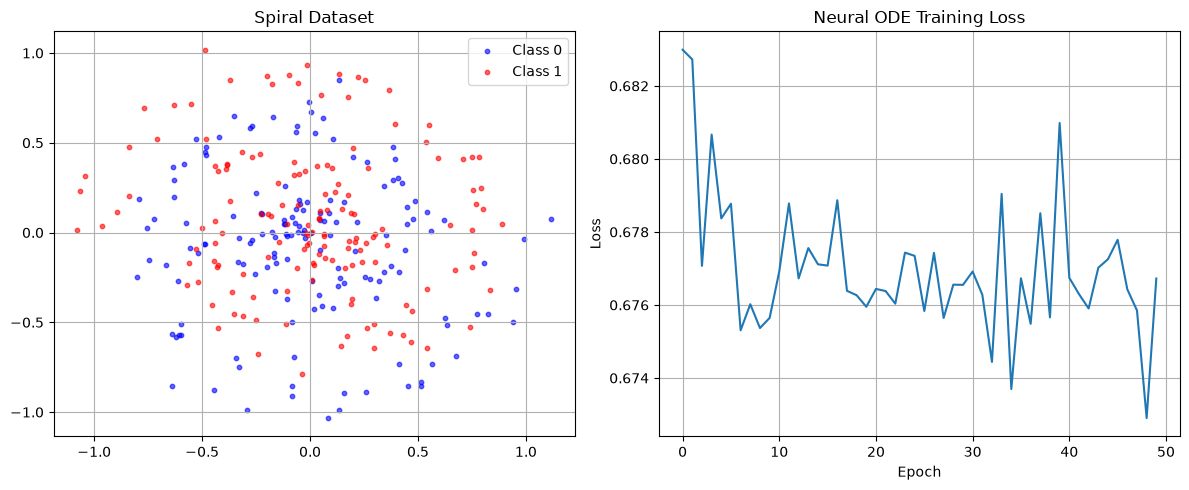

In [13]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

# Generate spiral dataset
def generate_spirals(n_points=200, noise=0.1):
    theta = np.linspace(0, 4 * np.pi, n_points)
    r = theta / (4 * np.pi)

    x1 = np.stack([r * np.cos(theta), r * np.sin(theta)], axis=1)
    x2 = np.stack([r * np.cos(theta + np.pi), r * np.sin(theta + np.pi)], axis=1)

    x1 += noise * np.random.randn(*x1.shape)
    x2 += noise * np.random.randn(*x2.shape)

    X = np.concatenate([x1, x2])
    y = np.concatenate([np.zeros(n_points), np.ones(n_points)])
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

X, y = generate_spirals(n_points=150)
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

# Neural ODE classifier
class SpiralODEFunc(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden)
        )
        self.nfe = 0

    def forward(self, t, h):
        self.nfe += 1
        return self.net(h)

class ODEClassifier(nn.Module):
    def __init__(self, input_dim=2, hidden=32, n_classes=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.Tanh()
        )
        self.ode_func = SpiralODEFunc(hidden)
        self.decoder = nn.Linear(hidden, n_classes)
        self.t = torch.linspace(0, 1, 10)

    def forward(self, x):
        h0 = self.encoder(x)
        if TORCHDIFFEQ_AVAILABLE:
            t = self.t.to(x.device)
            h_traj = odeint_adjoint(self.ode_func, h0, t, method='rk4')
            h1 = h_traj[-1]
        else:
            t = torch.linspace(0, 1, 10)
            h1 = rk4_solve(self.ode_func, h0, t)[-1]
        return self.decoder(h1)

model = ODEClassifier(input_dim=2, hidden=32, n_classes=2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Training loop
train_losses = []
for epoch in range(50):
    total_loss = 0
    for xb, yb in loader:
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_losses.append(total_loss / len(loader))

# Evaluate
with torch.no_grad():
    logits = model(X)
    preds = logits.argmax(dim=1)
    acc = (preds == y).float().mean().item()

print(f'Neural ODE Classifier on Spirals:')
print(f'  Final loss: {train_losses[-1]:.4f}')
print(f'  Accuracy:   {acc:.4f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Data
axes[0].scatter(X[y==0, 0], X[y==0, 1], c='blue', s=10, label='Class 0', alpha=0.6)
axes[0].scatter(X[y==1, 0], X[y==1, 1], c='red', s=10, label='Class 1', alpha=0.6)
axes[0].set_title('Spiral Dataset')
axes[0].legend()
axes[0].grid(True)

# Learning curve
axes[1].plot(train_losses)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Neural ODE Training Loss')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 14. Summary and Key Concepts

### Neural ODE Family Overview

| Model | Key Idea | Best For |
|---|---|---|
| Neural ODE | $dh/dt = f(h,t,\theta)$ | Classification, generation |
| Latent ODE | Encode + ODE in latent space | Irregular time series |
| GRU-ODE-Bayes | ODE + GRU updates at obs times | Clinical/irregular data |
| FFJORD | CNF + Hutchinson trace | Density estimation |
| HNN | Learn $\mathcal{H}(q,p)$ | Physical systems |
| LNN | Learn $\mathcal{L}(q, \dot{q})$ | Constrained mechanics |
| KAN | Learnable splines on edges | Scientific discovery |

### The Adjoint Method
The key insight enabling memory-efficient training:
$$\frac{d\mathcal{L}}{d\theta} = -\int_{t_1}^{t_0} \mathbf{a}(t)^T \frac{\partial f}{\partial \theta}\, dt$$
where $\mathbf{a}(t) = \frac{d\mathcal{L}}{d\mathbf{h}(t)}$

### Normalizing Flows Hierarchy
```
Normalizing Flows
├── Discrete NF
│   ├── NICE (additive coupling)
│   ├── RealNVP (affine coupling)
│   ├── Glow (1x1 conv + ActNorm + RealNVP)
│   ├── MAF (masked autoregressive, fast eval)
│   └── IAF (inverse autoregressive, fast sample)
└── Continuous NF
    └── FFJORD (Neural ODE + Hutchinson trace)
```

### KAN vs MLP
- **MLP**: fixed activations on nodes, scalar weights on edges
- **KAN**: learnable splines on edges, no weights: $y = (\Phi_{L-1} \circ \cdots \circ \Phi_0)\mathbf{x}$

## Additional Learning Resources

### Original Papers

1. **Neural ODEs**: Chen, R.T.Q., Rubanova, Y., Bettencourt, J., Duvenaud, D. (2018). *Neural Ordinary Differential Equations*. NeurIPS 2018. https://arxiv.org/abs/1806.07366

2. **FFJORD**: Grathwohl, W., Chen, R.T.Q., Bettencourt, J., Sutskever, I., Duvenaud, D. (2018). *FFJORD: Free-Form Continuous Dynamics for Scalable Reversible Generative Models*. ICLR 2019. https://arxiv.org/abs/1810.01367

3. **Latent ODE**: Rubanova, Y., Chen, R.T.Q., Duvenaud, D. (2019). *Latent Ordinary Differential Equations for Irregularly-Sampled Time Series*. NeurIPS 2019. https://arxiv.org/abs/1907.03907

4. **GRU-ODE-Bayes**: De Brouwer, E., Simm, J., Arany, A., Moreau, Y. (2019). *GRU-ODE-Bayes: Continuous Modelling of Sporadically-Observed Time Series*. NeurIPS 2019. https://arxiv.org/abs/1905.12374

5. **Hamiltonian NN**: Greydanus, S., Dzamba, M., Yosinski, J. (2019). *Hamiltonian Neural Networks*. NeurIPS 2019. https://arxiv.org/abs/1906.01563

6. **Lagrangian NN**: Cranmer, M., Greydanus, S., Hoyer, S., Battaglia, P., Spergel, D., Ho, S. (2020). *Lagrangian Neural Networks*. ICLR 2020 Workshop. https://arxiv.org/abs/2003.04630

7. **NICE**: Dinh, L., Krueger, D., Bengio, Y. (2014). *NICE: Non-linear Independent Components Estimation*. ICLR 2015 Workshop. https://arxiv.org/abs/1410.8516

8. **RealNVP**: Dinh, L., Sohl-Dickstein, J., Bengio, S. (2016). *Density Estimation Using Real-Valued Non-Volume Preserving Transformations*. ICLR 2017. https://arxiv.org/abs/1605.08803

9. **Glow**: Kingma, D.P., Dhariwal, P. (2018). *Glow: Generative Flow with Invertible 1x1 Convolutions*. NeurIPS 2018. https://arxiv.org/abs/1807.03039

10. **MAF**: Papamakarios, G., Pavlakou, T., Murray, I. (2017). *Masked Autoregressive Flow for Density Estimation*. NeurIPS 2017. https://arxiv.org/abs/1705.07057

11. **IAF**: Kingma, D.P., Salimans, T., Josefowicz, R., Chen, X., Sutskever, I., Wierstra, D. (2016). *Improving Variational Inference with Inverse Autoregressive Flow*. NeurIPS 2016. https://arxiv.org/abs/1606.04934

12. **KAN**: Liu, Z., Wang, Y., Vaidya, S., Ruehle, F., Halverson, J., Soljacic, M., Hou, T.Y., Tegmark, M. (2024). *KAN: Kolmogorov-Arnold Networks*. https://arxiv.org/abs/2404.19756

### Code Libraries

- **torchdiffeq**: https://github.com/rtqichen/torchdiffeq Official Neural ODE library with Dopri5, adjoint method
- **torchcde**: https://github.com/patrick-kidger/torchcde Neural Controlled Differential Equations
- **torchsde**: https://github.com/google-research/torchsde Stochastic Differential Equations
- **pykan**: https://github.com/KindXiaoming/pykan Official KAN implementation
- **nflows**: https://github.com/bayesiains/nflows Normalizing flows library (NICE, RealNVP, MAF, etc.)
- **normflows**: https://github.com/VincentStimper/normalizing-flows Another NF library

### Courses and Tutorials

- **Ricky T.Q. Chen's GitHub**: https://github.com/rtqichen Neural ODE author's code
- **Patrick Kidger's PhD Thesis**: *On Neural Differential Equations* (2022) Comprehensive treatment https://arxiv.org/abs/2202.02435
- **Normalizing Flows Tutorial**: Papamakarios et al. (2021). *Normalizing Flows for Probabilistic Modeling and Inference*. JMLR. https://arxiv.org/abs/1912.02762
- **Lilian Weng Blog**: *Flow-based Deep Generative Models* https://lilianweng.github.io/posts/2018-10-13-flow-models/
- **Emilien Dupont Blog**: *Understanding Neural ODEs* Clear visual explanation
- **DeepMind x UCL Lecture**: Advanced Deep Learning Neural ODEs (YouTube)

### Useful Background

- **Numerical Methods for ODEs**: Hairer, Norsett, Wanner *Solving Ordinary Differential Equations I* (classic textbook)
- **Classical Mechanics**: Goldstein, Poole, Safko *Classical Mechanics* (for Hamiltonian/Lagrangian background)
- **Variational Inference**: Blei et al. (2017). *Variational Inference: A Review for Statisticians*. JASA. https://arxiv.org/abs/1601.00670